In [22]:
import os, sys

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    if not os.path.exists("Scaling-book"):
        !git clone https://github.com/arjuns238/Scaling-book.git
    %cd Scaling-book/Addition_Transformer
    !pip install -q flax optax

Cloning into 'Scaling-book'...
remote: Enumerating objects: 118, done.
remote: Counting objects: 100% (118/118), done.
remote: Compressing objects: 100% (88/88), done.
remote: Total 118 (delta 73), reused 69 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (118/118), 244.25 KiB | 10.18 MiB/s, done.
Resolving deltas: 100% (73/73), done.
/content/Scaling-book/Addition_Transformer/Scaling-book/Addition_Transformer/Scaling-book/Addition_Transformer


In [23]:
import jax
jax.devices()

[TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0)]

In [15]:
# # chose configs - ~10M params
from model import *
from data import build_dataset, generate_split, Dataloader
import numpy as np
from config import Config
base_cfg = Config(
    d_model=384,
    ffw_multiplier=8/3,
    num_layers=6,
    query_heads=6,
    kv_heads=6,
    key_dim=64,
    vocab_size=16,
    batch_size = 256,
    dtype=jnp.bfloat16,
    lr = 1e-3,
    num_epochs = 15,
)

In [4]:
from utils import *

# Precompute (d_model, num_layers, N) once so we can pick sizes by N.
def size_table(base, SIZE_LADDER):
    table = []
    for dm, nl in SIZE_LADDER:
        w = Weights.init(make_cfg(base, dm, nl), jax.random.key(0))
        table.append((dm, nl, count_params(w)))
    return table  # list of (d_model, num_layers, N)

The smallest model is N=100,416. 

With N_min = 100416 and SUP_PER_EX ≈ 4 ( supervised tokens per example —, it's roughly the answer digits + EOS, so ~4 for the 2-and-3-digit-dominated draw).

The hard ceiling is distinct non-fundamental pairs: ~999,900. Fundamental pairs are defined as the cases with 1-digit addition as they are the fundamentals for all other cases. These are excluded from loss calculation.

To stay single-epoch (all fresh data, clean Chinchilla regime), the largest feasible budget for the smallest model:

C_max <= 6 * N_min * SUP_PER_EX * POOL_EXAMPLES
      =  6 * 100416 * 4 * 999900
      ≈  2,409,743,001,600
      ≈  2.4e12

In [5]:
from data import create_example
def build_full_pool(max_seq_len, max_n=1000, seed=0, exclude_both_1digit=True):
    pairs = []
    for a in range(max_n):
        for b in range(max_n):
            if exclude_both_1digit and a < 10 and b < 10:
                continue
            pairs.append((a, b))
    rng = np.random.default_rng(seed)
    rng.shuffle(pairs)  # so any prefix is a representative sample, not a-major

    n = len(pairs)
    tokens = np.empty((n, max_seq_len), dtype=np.int32)
    masks  = np.empty((n, max_seq_len), dtype=np.int32)
    for i, (a, b) in enumerate(pairs):
        t, m = create_example(a, b, max_seq_len)   # your fn
        tokens[i] = t
        masks[i]  = m
    return tokens, masks

In [9]:
def budget_ceiling(N_min, sup_per_ex, n_unique_train):
    """Largest C at which the smallest model still trains single-epoch."""
    D_max_tokens = n_unique_train * sup_per_ex
    return 6 * N_min * D_max_tokens

def examples_for(C, N, sup_per_ex):
    return int(round(C / (6 * N * sup_per_ex)))

In [10]:
# ----------------------------------------------------------------------
# 5. Corner check: 4 extremes -> go/no-go before the full sweep.
# ----------------------------------------------------------------------
def corner_check(base_cfg, tbl, budgets, train_tok, train_mask,
                 val_tok, val_mask, sup_per_ex, batch_size):
    n_train = len(train_tok)
    smallest, largest = tbl[0], tbl[-1]
    corners = [(budgets[0], smallest), (budgets[0], largest),
               (budgets[-1], smallest), (budgets[-1], largest)]
    print(corners)
    print(f"{'C':>10} {'N':>11} {'examples':>10} {'feasible':>9}  val_loss")
    results = []
    for C, (dm, nl, N) in corners:
        ne = examples_for(C, N, sup_per_ex)
        print("ne",ne) 
        feasible = ne <= n_train
        if feasible:
            vl = train_isoflop_point(
                make_cfg(base_cfg, dm, nl), train_tok, train_mask,
                val_tok, val_mask, ne, batch_size, base_cfg.lr)
        else:
            vl = float("nan")
        results.append((C, N, ne, feasible, vl))
        print(f"{C:>10.1e} {N:>11,} {ne:>10,} {str(feasible):>9}  {vl:.4f}")

    losses = [r[4] for r in results if r[3]]
    if any(not r[3] for r in results):
        print("\n[!] Some corners INFEASIBLE (need repeats). Lower C_max.")
    elif len(losses) >= 2 and (max(losses) - min(losses)) < 0.05:
        print("\n[!] Corner losses nearly identical -> valleys likely flat "
              "(saturated or starved). Adjust budget range before full sweep.")
    else:
        print(f"\n[ok] Corners span {max(losses)-min(losses):.3f} loss -> "
              "grid has dynamic range. Proceed to full sweep.")
    return results

In [11]:
POOL_TOK, POOL_MASK = build_full_pool(cfg.max_seq_len, seed=0)
SUP_PER_EX = float(POOL_MASK.sum(axis=1).mean())
print(f"Average tokens per example: {SUP_PER_EX}")

Average tokens per example: 4.494599459945994


In [12]:
BATCH_SIZE = 256
VAL_SIZE = 20_000

SIZE_LADDER = [(64, 2), (96, 3), (128, 3), (192, 4), (256, 5), (384, 6)]
POOL_TOK, POOL_MASK = build_full_pool(cfg.max_seq_len, seed=0)
VAL_TOK,   VAL_MASK   = POOL_TOK[-VAL_SIZE:], POOL_MASK[-VAL_SIZE:]
TRAIN_TOK, TRAIN_MASK = POOL_TOK[:-VAL_SIZE], POOL_MASK[:-VAL_SIZE]

SUP_PER_EX = float(POOL_MASK.sum(axis=1).mean()) # average output tokens per example ≈ 4

# --- size ladder with real N ---
TBL = size_table(cfg, SIZE_LADDER)
N_MIN = min(N for *_, N in TBL)

# --- budget ceiling + working range ---
C_MAX = budget_ceiling(N_MIN, SUP_PER_EX, len(TRAIN_TOK))
C_MIN  = C_MAX / 2e1           # 3 decades; corner check will validate
BUDGETS = np.logspace(np.log10(C_MIN), np.log10(C_MAX), 5)
print(f"C_max={C_MAX:.2e}  C_min={C_MIN:.2e}")

# --- calibrate before committing ---
results = corner_check(cfg, TBL, BUDGETS, TRAIN_TOK, TRAIN_MASK,
                VAL_TOK, VAL_MASK, SUP_PER_EX, BATCH_SIZE)

C_max=2.65e+12  C_min=1.33e+11
[(np.float64(132677391723.78036), (64, 2, 100416)), (np.float64(132677391723.78036), (384, 6, 10634112)), (np.float64(2653547834475.6074), (64, 2, 100416)), (np.float64(2653547834475.6074), (384, 6, 10634112))]
         C           N   examples  feasible  val_loss
ne 48995
n_examples 48995
total steps 191
   1.3e+11     100,416     48,995      True  1.5989
ne 463
n_examples 463
total steps 1


ValueError: The cosine_decay_schedule requires positive decay_steps, got decay_steps=-49.

In [ ]:
# ----------------------------------------------------------------------
# 6. Full sweep: every (budget, size) point.
# ----------------------------------------------------------------------
import itertools
import pandas as pd

def run_sweep(base_cfg, tbl, budgets, train_tok, train_mask,
              val_tok, val_mask, sup_per_ex, batch_size):
    n_train = len(train_tok)
    rows = []
    for C, (dm, nl, N) in itertools.product(budgets, tbl):
        ne = examples_for(C, N, sup_per_ex)
        if ne > n_train or ne < batch_size:
            print(f"skip C={C:.1e} N={N:,} (ne={ne:,} out of range)")
            continue
        vl = train_isoflop_point(
            make_cfg(base_cfg, dm, nl), train_tok, train_mask,
            val_tok, val_mask, ne, batch_size, base_cfg.lr)
        D = ne * sup_per_ex
        rows.append({"C": C, "d_model": dm, "num_layers": nl, "N": N,
                     "n_examples": ne, "D": D, "val_loss": vl})
        print(f"C={C:.1e} N={N:>11,} ne={ne:>8,} -> val {vl:.4f}")
    return pd.DataFrame(rows)

# PART 2

In [16]:
import jax
import jax.numpy as jnp
import numpy as np
import optax
from scipy.optimize import least_squares
from config import Config

BATCH_SIZE     = 256
SEED           = 0
VAL_SUP_TOKENS = 100_000      # fixed val set, counted in supervised tokens
MAX_LEN        = 14
MAX_N          = 1000         # operands 0..999

# model ladder: (d_model, num_layers). Two small rungs added at the bottom.
# At D=4.3M the old ladder's losses spanned only 0.048 -> 0.007 across N - all four
# models had essentially solved the task, so alpha was being fitted from four
# numbers clustered on the floor. Models this small stay above the floor and give
# the N direction real signal.
MODEL_LADDER = [(32, 2), (48, 2), (64, 2), (96, 3),
                (128, 3), (192, 4), (256, 5), (384, 6)]

# per-model-size peak LR, held fixed across D. Generated by a rule rather than a
# hand table so new rungs cannot be forgotten; anchored on the old values
# ((64,2)=1.5e-3, (384,6)=5e-4 sit within a few percent of this curve).
def peak_lr(d_model):
    return 1.5e-3 * (64.0 / d_model) ** 0.5

PEAK_LR = {(dm, nl): peak_lr(dm) for dm, nl in MODEL_LADDER}

# data ladder in SUPERVISED tokens. Log-spaced across the window that survives the
# fit-range filter, rather than spanning the full range and losing most of it:
#   below ~575k a single epoch at batch 256 is under 500 optimizer steps
#     -> undertrained, not data-limited (the old 100k and 250k rungs)
#   above ~4.3M the pool is exhausted, and the top rungs are already at the floor
#     (beta between 2.8M and 4.3M measured -0.17, +0.44, +4.89 = noise)
# 8 rungs inside the window beats 6 spanning three regimes.
DATA_LADDER = [600_000, 795_000, 1_055_000, 1_400_000,
               1_850_000, 2_450_000, 3_250_000, 4_300_000]

In [17]:
# ============================================================================
# 1. Pool construction, fixed val carve, nested prefixes
# ============================================================================
from data import create_example

def build_pool(seed=SEED):
    """All non-fundamental pairs, shuffled once. Fundamentals = both operands
    single-digit (a<10 and b<10) -> memorized lookup, excluded."""
    toks, masks = [], []
    for a in range(MAX_N):
        for b in range(MAX_N):
            if a < 10 and b < 10:
                continue
            t, m = create_example(a, b, MAX_LEN)
            toks.append(t)
            masks.append(m)
    toks  = np.asarray(toks,  dtype=np.int32)
    masks = np.asarray(masks, dtype=np.int32)
    perm = np.random.default_rng(seed).permutation(len(toks))
    return toks[perm], masks[perm]

def supervised_tokens(masks):
    return int(masks.sum())


def carve_val(pool_tok, pool_mask, val_sup_tokens=VAL_SUP_TOKENS):
    """Fixed val set taken from the front of the shuffled pool; the remainder
    is the training pool. Val is identical for every cell."""
    cum = np.cumsum(pool_mask.sum(axis=1))
    n_val = int(np.searchsorted(cum, val_sup_tokens) + 1)
    return (pool_tok[:n_val], pool_mask[:n_val],
            pool_tok[n_val:], pool_mask[n_val:])


def prefix_for_D(tr_tok, tr_mask, D_sup_tokens):
    """Nested prefix: fewest examples whose supervised tokens reach D."""
    cum = np.cumsum(tr_mask.sum(axis=1))
    n = min(int(np.searchsorted(cum, D_sup_tokens) + 1), len(tr_tok))
    return tr_tok[:n], tr_mask[:n]


def check_ladder(tr_mask, ladder=DATA_LADDER):
    """Verify every D is actually available; return the ceiling."""
    avail = supervised_tokens(tr_mask)
    print(f"train pool supervised tokens available: {avail:,}")
    for D in ladder:
        print(f"  D={D:>10,}  {'ok' if D <= avail else 'EXCEEDS POOL'}")
    if max(ladder) > avail:
        raise ValueError(
            f"largest D ({max(ladder):,}) exceeds pool ({avail:,}). "
            "Lower the top of DATA_LADDER.")
    return avail

In [18]:
# ============================================================================
# 2. Config / param counting
# ============================================================================
def make_cfg(base_cfg: Config, d_model, num_layers):
    """Scale heads with d_model, keeping key_dim pinned at 64.

    The previous version held heads at base_cfg's 6, so a d_model=32 model still
    carried 6x64 attention: 4DHL dominated and N bottomed out at ~116k no matter
    how small d_model got. Scaling heads makes the small rungs genuinely small
    (33k instead of 116k) and widens the ladder from 1.6 to 2.5 decades of N -
    which is what alpha is estimated from.
    """
    heads = max(1, d_model // base_cfg.key_dim)
    return base_cfg.replace(d_model=d_model, num_layers=num_layers,
                            query_heads=heads, kv_heads=heads)


def count_params(cfg: Config):
    w = Weights.init(cfg, jax.random.key(0))
    return int(sum(x.size for x in jax.tree_util.tree_leaves(w)))


In [19]:
# ============================================================================
# 3. Train one (N, D) cell — single epoch, matched cosine
# ============================================================================
import optax
from optax.losses import softmax_cross_entropy_with_integer_labels

def make_optimizer(peak_lr, total_steps, weight_decay=0.1):
    schedule = optax.warmup_cosine_decay_schedule(
        init_value=0.0,
        peak_value=peak_lr,
        # proportional warmup, capped at 50. The old max(50, ...) put 58% of a short
        # run into warmup, so small-D cells never trained at peak LR and flat-lined
        # at ~1.55 - which looked like a phase transition in the loss surface. It also
        # made decay_steps negative below 50 steps, killing those cells outright.
        warmup_steps=max(1, min(50, int(0.05 * total_steps))),
        decay_steps=total_steps,
        end_value=peak_lr * 0.1,
    )
    return optax.adamw(schedule, weight_decay=weight_decay)


def calc_val_loss(val_loader, weights, cfg):
    losses = [loss_fn(weights, x, m, cfg).item() for x, m in val_loader]
    return float(np.mean(losses))

def loss_fn(weights: jax.Array, token_ids: jax.Array, mask: jax.Array, cfg: Config) -> jax.Array:
    # forward now returns (logits, aux_loss, routing_stats). On the dense path the
    # aux loss is 0 and stats are None, so both are discarded here.
    logits, _lb, _stats = forward(token_ids[:, :-1], weights, cfg)
    targets = token_ids[:, 1:]
    # for addition, we need to build a mask because the model needs to only predict the last 3 digits
    # need mask code
    loss_mask = mask[:, 1:]
    loss = softmax_cross_entropy_with_integer_labels(logits, targets) # mean would also change since masking the outputs
    loss = jnp.sum(loss * loss_mask) / jnp.sum(loss_mask)
    return loss


# Single-seed noise exceeded the trend in the previous run: at D=600k the losses
# ran 0.62, 0.33, 1.54, 0.23, 0.13 as N increased - the 1.54 is a failed run, not a
# data point. Median over seeds is what makes the surface measurable.
# Set to (0, 1, 2) to take a median over seeds if outliers reappear.
SEEDS = (0,)


def train_cell(base_cfg, d_model, num_layers, tr_tok, tr_mask,
               val_tok, val_mask, seeds=SEEDS):
    losses = [_train_one(base_cfg, d_model, num_layers, tr_tok, tr_mask,
                         val_tok, val_mask, sd) for sd in seeds]
    return float(np.median(losses)), float(max(losses) - min(losses)), len(losses)


def _train_one(base_cfg, d_model, num_layers, tr_tok, tr_mask,
               val_tok, val_mask, seed=SEED):
    cfg = make_cfg(base_cfg, d_model, num_layers)
    total_steps = len(tr_tok) // BATCH_SIZE      # single epoch
    if total_steps < 1:
        raise ValueError(f"D too small for one batch: {len(tr_tok)} examples")

    weights = Weights.init(cfg, jax.random.key(seed))
    opt = make_optimizer(PEAK_LR[(d_model, num_layers)], total_steps)
    opt_state = opt.init(weights)

    @jax.jit
    def train_step(x, mask, weights, opt_state):
        # cfg is closed over so it stays a python constant under jit
        loss, grads = jax.value_and_grad(loss_fn)(weights, x, mask, cfg)
        updates, opt_state = opt.update(grads, opt_state, weights)
        weights = optax.apply_updates(weights, updates)
        return loss, weights, opt_state

    for x, m in Dataloader(tr_tok, tr_mask, BATCH_SIZE):
        _, weights, opt_state = train_step(x, m, weights, opt_state)

    return calc_val_loss(
        Dataloader(val_tok, val_mask, BATCH_SIZE, shuffle=False), weights, cfg)

In [20]:
# ============================================================================
# 4. Full-cross sweep (Part 1: measure the loss field, no compute constraint)
# ============================================================================
def run_sweep(base_cfg, seed=SEED):
    pool_tok, pool_mask = build_pool(seed)
    val_tok, val_mask, tr_tok, tr_mask = carve_val(pool_tok, pool_mask)

    print(f"pool: {len(pool_tok):,} ex, {supervised_tokens(pool_mask):,} sup-tok")
    print(f"val:  {len(val_tok):,} ex, {supervised_tokens(val_mask):,} sup-tok")
    D_ceiling = check_ladder(tr_mask)

    rows = []
    for (d_model, num_layers) in MODEL_LADDER:
        N = count_params(make_cfg(base_cfg, d_model, num_layers))
        for D in DATA_LADDER:
            sub_tok, sub_mask = prefix_for_D(tr_tok, tr_mask, D)
            D_actual = supervised_tokens(sub_mask)
            val_loss, spread, n_seeds = train_cell(
                base_cfg, d_model, num_layers, sub_tok, sub_mask, val_tok, val_mask)
            rows.append(dict(d_model=d_model, num_layers=num_layers, N=N,
                             D_target=D, D_actual=D_actual, val_loss=val_loss,
                             seed_spread=spread, n_seeds=n_seeds,
                             n_examples=len(sub_tok),
                             steps=len(sub_tok) // BATCH_SIZE))
            print(f"N={N:>9,}  D={D_actual:>9,}  val_loss={val_loss:.4f}"
                  f" (+/-{spread:.3f} over {n_seeds} seeds)")
    return rows, D_ceiling

In [ ]:
import json, time

# --- persist ---------------------------------------------------------------
# The Colab VM is ephemeral: anything written to /content disappears when the
# runtime recycles (this is how the previous rows.pkl was lost). Copy to Drive.
def save_rows(rows, D_ceiling, tag):
    def _jsonable(r):
        return {k: (v.tolist() if hasattr(v, 'tolist') else v) for k, v in r.items()}

    stamp = time.strftime('%Y%m%d-%H%M%S')
    path = f"rows_{tag}_{stamp}.json"
    payload = dict(rows=[_jsonable(r) for r in rows], D_ceiling=D_ceiling,
                   tag=tag, stamp=stamp)
    with open(path, "w") as f:
        json.dump(payload, f)
    print(f"saved {len(rows)} rows -> {path}")

    if IN_COLAB:
        from google.colab import drive
        import shutil, os
        if not os.path.exists('/content/drive'):
            drive.mount('/content/drive')
        dest_dir = '/content/drive/MyDrive/scaling-book'
        os.makedirs(dest_dir, exist_ok=True)
        shutil.copy(path, dest_dir)
        print(f"copied -> {dest_dir}/{path}")
    return path

rows, D_ceiling = run_sweep(base_cfg)
ROWS_PATH = save_rows(rows, D_ceiling, 'dense')



In [24]:
# ---------------------------------------------------------------------------
# Reload a previous sweep instead of retraining.
# Skip this cell if you just ran the sweep above - it would overwrite `rows`.
# ---------------------------------------------------------------------------
import json, os, glob
import numpy as np

DRIVE_DIR = "/content/drive/MyDrive/scaling-book"
ROWS_FILE = None          # set an explicit filename to pin a specific sweep,
                          # e.g. "rows_dense_20260803-023957.json"

def load_rows(path=None, tag="dense"):
    """Load a saved sweep. With no path, takes the newest rows_<tag>_*.json from
    Drive, falling back to the working directory."""
    if path is None:
        if IN_COLAB and not os.path.exists("/content/drive"):
            from google.colab import drive
            drive.mount("/content/drive")
        cands = sorted(glob.glob(os.path.join(DRIVE_DIR, f"rows_{tag}_*.json"))
                       + glob.glob(f"rows_{tag}_*.json"))
        if not cands:
            raise FileNotFoundError(
                f"no rows_{tag}_*.json in {DRIVE_DIR} or {os.getcwd()}")
        path = cands[-1]                      # timestamped names sort chronologically
    elif not os.path.exists(path) and os.path.exists(os.path.join(DRIVE_DIR, path)):
        path = os.path.join(DRIVE_DIR, path)  # bare filename -> look in Drive

    with open(path) as f:
        payload = json.load(f)
    rows = payload["rows"]
    for r in rows:                            # frac round-trips through json as a list
        if "frac" in r:
            r["frac"] = np.asarray(r["frac"])
    print(f"loaded {len(rows)} rows from {path}")
    print(f"  D_ceiling={payload['D_ceiling']:,}  saved={payload.get('stamp', 'unknown')}")
    return rows, payload["D_ceiling"]


rows, D_ceiling = load_rows(ROWS_FILE)


Mounted at /content/drive
loaded 64 rows from /content/drive/MyDrive/scaling-book/rows_dense_20260803-023957.json
  D_ceiling=4,394,147  saved=20260803-023957


In [25]:
# ============================================================================
# 4b. Fit range — keep only the power-law regime
# ============================================================================
# Loss vs data moves through three regimes: random-guessing plateau -> power law
# -> irreducible floor. E + A/N^a + B/D^b describes only the middle one. Fitting
# across all three is a known failure mode: including the guessing regime biases
# the exponent down, and including the saturated regime does too. Standard
# practice is to exclude both ends and SAY which points were dropped.
#
# There is a second reason to drop the floor here: fit_surface takes residuals on
# log(loss), so with losses reaching ~1e-3 a 0.001 -> 0.002 wiggle carries the same
# weight as 0.8 -> 1.6. Saturated points would dominate the fit.

def guessing_baseline(tok, mask):
    """Loss of a position-conditional unigram predictor on the val set: the model
    knows the output format and token frequencies but no arithmetic. Any cell at
    or above this has not left the guessing regime. Pure data statistic - no
    training involved."""
    tgt, lm = np.asarray(tok)[:, 1:], np.asarray(mask)[:, 1:]
    sup = tgt[lm == 1]
    pos = np.tile(np.arange(tgt.shape[1]), (len(tgt), 1))[lm == 1]
    V = int(tgt.max()) + 1
    H = 0.0
    for q in np.unique(pos):
        s = sup[pos == q]
        p = np.bincount(s, minlength=V) / len(s)
        H += len(s) / len(sup) * -np.sum(p[p > 0] * np.log(p[p > 0]))
    return float(H)


def select_fit_range(rows, L_guess, guess_frac=0.90, sat_mult=3.0,
                     min_steps=500, floor=None, min_N=None, verbose=True):
    """Return the subset of rows inside the power-law regime.

    guess_frac  drop cells with loss >= guess_frac * L_guess (still guessing)
    sat_mult    drop cells with loss <= sat_mult * floor     (saturated)
    min_steps   drop cells whose run was too short to converge, independent of loss.
                Single-epoch couples D to optimizer steps, so a small-D cell can be
                undertrained rather than data-limited - those are not points on the
                loss-vs-data curve at all.
    floor       irreducible loss estimate; defaults to the best loss observed.
    min_N       drop rungs below this N. Capacity-limited models sit near the
                guessing plateau with beta ~ 0 (measured 0.15 +/- 0.05 for
                N <= 298k here, vs 1.34 +/- 0.25 above). That is a different
                regime, and leaving it in makes the D term explain flatness.
    """
    L = np.array([r['val_loss'] for r in rows], dtype=float)
    floor = float(L.min()) if floor is None else float(floor)
    hi, lo = guess_frac * L_guess, sat_mult * floor

    keep, drop = [], []
    for r in rows:
        why = []
        if r['val_loss'] >= hi:
            why.append('guessing')
        if r['val_loss'] <= lo:
            why.append('saturated')
        if r.get('steps') is not None and r['steps'] < min_steps:
            why.append(f"undertrained({r['steps']}<{min_steps}steps)")
        if min_N is not None and r['N'] < min_N:
            why.append('capacity-limited(N)')
        (drop if why else keep).append((r, why))

    if verbose:
        print(f"fit range: {hi:.4f} > loss > {lo:.4f}   (guessing baseline {L_guess:.4f}, "
              f"observed floor {floor:.5f}, min {min_steps} steps)")
        print(f"  kept {len(keep)} / {len(rows)} cells")
        reasons = {}
        for _, why in drop:
            reasons[', '.join(why)] = reasons.get(', '.join(why), 0) + 1
        for k, v in sorted(reasons.items(), key=lambda kv: -kv[1]):
            print(f"    dropped {v:>3}  {k}")
        if len(keep) < 8:
            print("  [!] fewer than 8 points left - a 5-parameter surface is not "
                  "identifiable here. Densify the ladder inside this window.")
    return [r for r, _ in keep]


def local_beta(rows, verbose=True):
    """beta = -dlogL/dlogD between adjacent D rungs at fixed N. A genuine power law
    has CONSTANT beta; drift across the row is what tells you a regime boundary was
    crossed. Run this on the KEPT rows to check the window is really power-law."""
    out = {}
    for N in sorted({r['N'] for r in rows}):
        d = sorted(((r['D_actual'], r['val_loss']) for r in rows if r['N'] == N))
        betas = [-(np.log(b[1]) - np.log(a[1])) / (np.log(b[0]) - np.log(a[0]))
                 for a, b in zip(d, d[1:])]
        out[N] = betas
        if verbose and betas:
            spread = max(betas) / max(min(betas), 1e-9) if min(betas) > 0 else float('inf')
            flag = 'ok' if spread < 3 else 'NOT constant - window still spans a regime edge'
            print(f"  N={int(N):>10,}  beta={[round(b,2) for b in betas]}  {flag}")
    return out

# --- apply -----------------------------------------------------------------
_pt, _pm = build_pool(SEED)
_vt, _vm, _, _ = carve_val(_pt, _pm)
L_GUESS = guessing_baseline(_vt, _vm)

# MIN_N: below this the models are capacity-limited (beta ~ 0), a different regime.
# Set to None to keep every rung.
MIN_N = 500_000
fit_rows = select_fit_range(rows, L_GUESS, min_N=MIN_N)
print()
print("local beta on the kept window (should be roughly constant):")
_ = local_beta(fit_rows)


fit range: 1.6070 > loss > 0.0151   (guessing baseline 1.7855, observed floor 0.00505, min 500 steps)
  kept 24 / 64 cells
    dropped  31  capacity-limited(N)
    dropped   8  saturated
    dropped   1  guessing, capacity-limited(N)

local beta on the kept window (should be roughly constant):
  N=   594,432  beta=[np.float64(2.07), np.float64(0.9), np.float64(5.3), np.float64(-4.97), np.float64(-0.01), np.float64(6.4), np.float64(4.8)]  NOT constant - window still spans a regime edge
  N= 1,777,344  beta=[np.float64(5.22), np.float64(0.25), np.float64(-0.38), np.float64(4.13), np.float64(3.45), np.float64(-3.29)]  NOT constant - window still spans a regime edge
  N= 3,940,608  beta=[np.float64(1.57), np.float64(4.05), np.float64(1.04), np.float64(0.35)]  NOT constant - window still spans a regime edge
  N=10,634,112  beta=[np.float64(4.42), np.float64(0.25), np.float64(-0.62)]  NOT constant - window still spans a regime edge


         C  cells  N pts    argmin N    L min  verdict
  1.85e+11      3      2      33,888   1.4638  too-thin
  1.84e+12     10      5      33,888   0.5595  edge-low
  1.82e+13      8      4     594,432   0.0256  interior
  1.81e+14      4      3   1,777,344   0.0004  edge-low

the param/data split behind every point (fixed C, so N up <=> D down):
  --- C = 1.85e+11 ----------------------------------------------
               N            D      D/N   actual C     loss  cells
          33,888      925,002     27.3   1.88e+11   1.4638      2
          63,216      600,002      9.5   2.28e+11   1.5516      1
  --- C = 1.84e+12 ----------------------------------------------
               N            D      D/N   actual C     loss  cells
          33,888    8,852,691    261.2   1.80e+12   0.5595      1
          63,216    3,775,001     59.7   1.43e+12   1.1464      2
         100,416    3,250,003     32.4   1.96e+12   1.1494      3
         298,656    1,055,002      3.5   1.89e+12   1.5

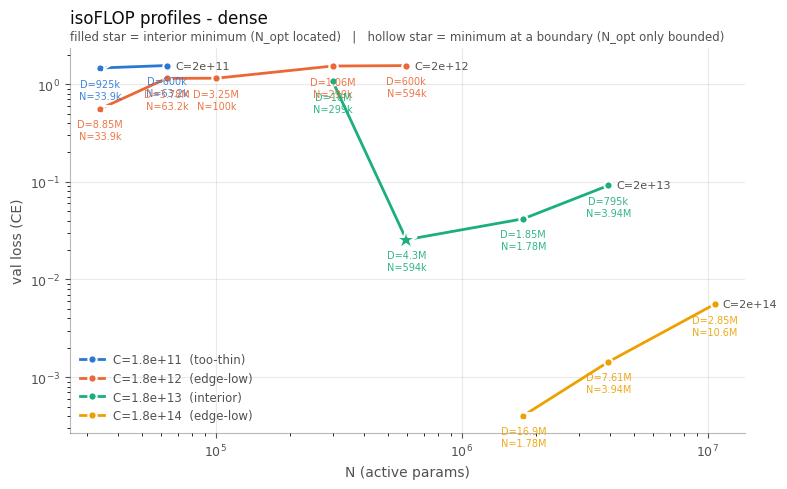

[{'C': 184650244411.98553,
  'pts': [{'N': 33888,
    'loss': 1.4637990552325582,
    'D': 925002.5,
    'C': 188078908320.0,
    'k': 2},
   {'N': 63216,
    'loss': 1.5515988372093024,
    'D': 600002.0,
    'C': 227578358592.0,
    'k': 1}],
  'n_cells': 3},
 {'C': 1835158459019.1965,
  'pts': [{'N': 33888,
    'loss': 0.5594567587209303,
    'D': 8852691.218130311,
    'C': 1799999999999.9998,
    'k': 1},
   {'N': 63216,
    'loss': 1.1463935319767442,
    'D': 3775001.5,
    'C': 1431842968944.0,
    'k': 2},
   {'N': 100416,
    'loss': 1.149436773255814,
    'D': 3250003.0,
    'C': 1958113807488.0,
    'k': 3},
   {'N': 298656,
    'loss': 1.5330668604651163,
    'D': 1055002.0,
    'C': 1890496063872.0,
    'k': 3},
   {'N': 594432,
    'loss': 1.5482376453488371,
    'D': 600002.0,
    'C': 2139962333184.0,
    'k': 1}],
  'n_cells': 10},
 {'C': 18238841656746.402,
  'pts': [{'N': 298656,
    'loss': 1.0643168604651163,
    'D': 10045001.607200257,
    'C': 18000000000000.0,

In [39]:
# ============================================================================
# isoFLOP profiles — does a compute-optimal N even exist here?
# ============================================================================
# Chinchilla's Approach 2: fix C = 6ND, sweep N, and the loss-vs-N curve is a U.
# The left arm rises because the model is too small; the right arm rises because
# at fixed C a bigger model gets proportionally less data and is undertrained.
# N_opt is the bottom of the U.
#
# Both arms have to rise for a minimum to exist. If capacity always helps and data
# never binds in the range tested, the curve is monotonically DECREASING and the
# "optimum" is just the largest model you ran - a boundary artifact, not a result.
# These functions check which case you are in instead of assuming the U.
#
# NOTE: no MIN_N filter here. The capacity-limited small rungs are exactly the
# left arm of the U - they are excluded from the surface fit, but needed here.

import matplotlib.pyplot as plt
import numpy as np

_INK, _MUTED = "#0b0b0b", "#52514e"
_SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]


def add_compute(rows, kappa=6.0):
    for r in rows:
        r['C'] = kappa * r['N'] * r['D_actual']
    return rows


def isoflop_bands(rows, n_bands=4, tol=0.18, min_points=1):
    """Group cells into log-spaced compute bands.

    C is derived, not chosen: C = 6*N*D_actual for every cell you trained, then
    n_bands log-spaced centres are placed between the min and max observed C and
    each cell joins the centre it is within tol decades of. A grid sweep has no
    exact isoFLOP lines, hence the tolerance. Bands with fewer than 3 distinct N
    min_points controls how thin a band may be. A band with fewer than 3 distinct
    N cannot show an interior minimum by construction, so it is reported as
    'too-thin' rather than 'edge-*' - it carries no verdict either way.

    Each point keeps the D values behind it, since at fixed C the whole story is
    how the budget was split between params and data.
    """
    add_compute(rows)
    C = np.array([r['C'] for r in rows])
    centres = np.logspace(np.log10(C.min()) + tol, np.log10(C.max()) - tol, n_bands)
    bands = []
    for c in centres:
        members = [r for r in rows if abs(np.log10(r['C'] / c)) <= tol]
        by_N = {}
        for r in members:                       # several D can land in one band per N
            by_N.setdefault(r['N'], []).append(r)
        pts = []
        for n, rs in sorted(by_N.items()):
            pts.append(dict(N=n,
                            loss=float(np.median([r['val_loss'] for r in rs])),
                            D=float(np.median([r['D_actual'] for r in rs])),
                            C=float(np.median([r['C'] for r in rs])),
                            k=len(rs)))
        if len(pts) >= min_points:
            bands.append(dict(C=float(c), pts=pts, n_cells=len(members)))
    return bands


def classify_band(band):
    """interior = a real optimum; edge-low / edge-high = the minimum is at a boundary
    and N_opt is not measured, only bounded; too-thin = fewer than 3 N, so an
    interior minimum could not be detected even if one existed."""
    Ls = [p['loss'] for p in band['pts']]
    j = int(np.argmin(Ls))
    if len(Ls) < 3:
        kind = 'too-thin'
    elif 0 < j < len(Ls) - 1:
        kind = 'interior'
    else:
        kind = 'edge-low' if j == 0 else 'edge-high'
    return kind, band['pts'][j]['N'], Ls[j]


def isoflop_report(rows, n_bands=4, tol=0.18, detail=True, min_points=1):
    bands = isoflop_bands(rows, n_bands, tol, min_points)
    print(f"{'C':>10} {'cells':>6} {'N pts':>6} {'argmin N':>11} {'L min':>8}  verdict")
    verdicts = []
    for b in bands:
        kind, n_best, l_best = classify_band(b)
        verdicts.append(kind)
        print(f"{b['C']:>10.2e} {b['n_cells']:>6} {len(b['pts']):>6} "
              f"{int(n_best):>11,} {l_best:>8.4f}  {kind}")
    if detail:
        print()
        print("the param/data split behind every point (fixed C, so N up <=> D down):")
        for b in bands:
            print(f"  --- C = {b['C']:.2e} " + "-" * 46)
            print(f"     {'N':>11} {'D':>12} {'D/N':>8} {'actual C':>10} "
                  f"{'loss':>8} {'cells':>6}")
            for p in b['pts']:
                print(f"     {int(p['N']):>11,} {int(p['D']):>12,} "
                      f"{p['D']/p['N']:>8.1f} {p['C']:>10.2e} "
                      f"{p['loss']:>8.4f} {p['k']:>6}")
    print()
    verdicts = [v for v in verdicts if v != 'too-thin']   # thin bands carry no verdict
    n_int = verdicts.count('interior')
    if not verdicts:
        print("every band is too thin to classify - widen tol or add N rungs.")
        return bands
    if n_int == 0:
        print("NO band has an interior minimum.")
        print("  -> loss decreases monotonically in N at fixed compute across the whole")
        print("     range tested. There is no compute-optimal model size here: the best")
        print("     N is always the largest one run. A Chinchilla frontier cannot be")
        print("     measured from this data - not because the fit failed, but because")
        print("     the optimum lies outside the range (or does not exist at this scale).")
    elif n_int < len(verdicts):
        print(f"{n_int}/{len(verdicts)} bands have an interior minimum - partial coverage.")
        print("  -> N_opt is measured only where the verdict is 'interior'; elsewhere it")
        print("     is bounded, not located.")
    else:
        print("All bands have interior minima - isoFLOP profiles are well posed.")
    return bands


def plot_isoflop(rows, n_bands=4, tol=0.18, title="isoFLOP profiles", min_points=1):
    bands = isoflop_bands(rows, n_bands, tol, min_points)
    fig, ax = plt.subplots(figsize=(8, 5))
    def _si(x):
        for div, suf in ((1e9, 'B'), (1e6, 'M'), (1e3, 'k')):
            if x >= div:
                return f"{x/div:.3g}{suf}"
        return f"{x:.0f}"

    for i, b in enumerate(bands):
        Ns = [p['N'] for p in b['pts']]; Ls = [p['loss'] for p in b['pts']]
        col = _SERIES[i % len(_SERIES)]
        kind, n_best, l_best = classify_band(b)
        ax.plot(Ns, Ls, 'o-', color=col, lw=2, markersize=6,
                markeredgecolor='white', markeredgewidth=1.5,
                label=f"C={b['C']:.1e}  ({kind})")
        # hollow marker where the optimum is only bounded, filled where it is located
        ax.plot([n_best], [l_best], marker='*', markersize=16, color=col,
                markeredgecolor='white', markeredgewidth=1.5,
                fillstyle='full' if kind == 'interior' else 'none', zorder=5)
        # per-point split: at fixed C the interesting number is how much data the
        # cell got, so label D directly rather than making the reader compute it
        for p in b['pts']:
            ax.annotate(f"D={_si(p['D'])}\nN={_si(p['N'])}",
                        xy=(p['N'], p['loss']), xytext=(0, -22),
                        textcoords='offset points', ha='center', fontsize=7,
                        linespacing=1.25, color=col, alpha=0.9)
        ax.annotate(f"C={b['C']:.0e}", xy=(Ns[-1], Ls[-1]), xytext=(6, 0),
                    textcoords='offset points', va='center', fontsize=8, color=_MUTED)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel("N (active params)", color=_MUTED, fontsize=10)
    ax.set_ylabel("val loss (CE)", color=_MUTED, fontsize=10)
    ax.set_title(title, color=_INK, fontsize=12, loc='left', pad=18)
    ax.text(0.0, 1.02, "filled star = interior minimum (N_opt located)   |   "
            "hollow star = minimum at a boundary (N_opt only bounded)",
            transform=ax.transAxes, fontsize=8.5, color=_MUTED)
    ax.grid(True, color=_MUTED, alpha=0.12, lw=0.8); ax.set_axisbelow(True)
    for s in ('top', 'right'): ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'): ax.spines[s].set_color(_MUTED); ax.spines[s].set_alpha(0.4)
    ax.tick_params(colors=_MUTED, labelsize=9)
    ax.legend(frameon=False, fontsize=8.5, labelcolor=_MUTED, loc='lower left')
    fig.tight_layout(); plt.show()
    return bands


# ----------------------------------------------------------------------------
# The comparison that survives the noise: best loss at matched compute
# ----------------------------------------------------------------------------
# Locating an argmin under sd~0.5 noise is hopeless; reading off the MINIMUM VALUE
# is far more robust, because it only needs the envelope, not its position.
# This answers "does moe buy anything at matched compute" without estimating a
# single scaling parameter.

def best_loss_vs_compute(rows, group_key='n_experts', n_bands=5, tol=0.18):
    add_compute(rows)
    groups = sorted({r.get(group_key, 0) for r in rows})
    C = np.array([r['C'] for r in rows])
    centres = np.logspace(np.log10(C.min()) + tol, np.log10(C.max()) - tol, n_bands)
    out = {}
    for g in groups:
        sub = [r for r in rows if r.get(group_key, 0) == g]
        series = []
        for c in centres:
            mem = [r for r in sub if abs(np.log10(r['C'] / c)) <= tol]
            if len(mem) >= 2:
                best = min(mem, key=lambda r: r['val_loss'])
                series.append((float(c), best['val_loss'], best['N'], len(mem)))
        out[g] = series
    return out


def report_best_loss(res, group_key='n_experts'):
    print(f"{'group':>8} {'C':>10} {'best loss':>10} {'at N':>11} {'cells':>6}")
    for g, series in res.items():
        label = 'dense' if g == 0 else f'{group_key}={g}'
        for c, l, n, k in series:
            print(f"{label:>8} {c:>10.2e} {l:>10.4f} {int(n):>11,} {k:>6}")
    base = res.get(0)
    if base and len(res) > 1:
        print()
        print("relative to dense at matched compute (negative = moe better):")
        bmap = {round(np.log10(c), 2): l for c, l, _, _ in base}
        for g, series in res.items():
            if g == 0:
                continue
            deltas = [(c, l / bmap[round(np.log10(c), 2)])
                      for c, l, _, _ in series if round(np.log10(c), 2) in bmap]
            if deltas:
                txt = '  '.join(f"{c:.0e}:{r:>5.2f}x" for c, r in deltas)
                print(f"  E={g:<3} {txt}")


def plot_best_loss(res, group_key='n_experts', title="Best loss at matched compute"):
    fig, ax = plt.subplots(figsize=(8, 5))
    for i, (g, series) in enumerate(sorted(res.items())):
        if not series:
            continue
        label = 'dense' if g == 0 else f'E={g}'
        col = _MUTED if g == 0 else _SERIES[(i - 1) % len(_SERIES)]
        Cs = [s[0] for s in series]; Ls = [s[1] for s in series]
        ax.plot(Cs, Ls, 'o-', color=col, lw=2, markersize=6,
                markeredgecolor='white', markeredgewidth=1.5, label=label)
        ax.annotate(label, xy=(Cs[-1], Ls[-1]), xytext=(6, 0),
                    textcoords='offset points', va='center', fontsize=9, color=_MUTED)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel("compute C = 6ND (FLOPs)", color=_MUTED, fontsize=10)
    ax.set_ylabel("best val loss achieved", color=_MUTED, fontsize=10)
    ax.set_title(title, color=_INK, fontsize=12, loc='left', pad=10)
    ax.grid(True, color=_MUTED, alpha=0.12, lw=0.8); ax.set_axisbelow(True)
    for s in ('top', 'right'): ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'): ax.spines[s].set_color(_MUTED); ax.spines[s].set_alpha(0.4)
    ax.tick_params(colors=_MUTED, labelsize=9)
    ax.legend(frameon=False, fontsize=9, labelcolor=_MUTED)
    fig.tight_layout(); plt.show()


# --- apply -----------------------------------------------------------------
# rows, not fit_rows: the isoFLOP profile needs the capacity-limited small rungs
# as the left arm of the U.
bands = isoflop_report(rows)
plot_isoflop(rows, title="isoFLOP profiles - dense")


In [36]:
# ============================================================================
# Multi-epoch infill — fill thin isoFLOP bands without retraining anything
# ============================================================================
# A rectangular (N, D) grid makes DIAGONAL isoFLOP lines, so the extreme compute
# bands always end up with one or two models. Reaching them with a smaller model
# needs D beyond the pool, i.e. repeats. Muennighoff et al. find up to ~4 epochs
# of repetition is worth roughly as much as fresh data, so MAX_EPOCHS=4 is the
# cap; past that the repeated tokens are worth measurably less and D stops meaning
# what the scaling law assumes.
#
# Everything here ADDS rows. train_cell and the existing sweep are untouched, so
# the cells you already have stay exactly as they were - which is the point:
# infill points must be comparable to the grid they are filling in.
#
# LR: peak LR stays a function of model size only (the same PEAK_LR the existing
# rows used). Retuning it here would make the new cells incomparable to the old.

MAX_EPOCHS = 4.0


def cycling_loader(tok, mask, batch_size, n_steps, seed=0):
    """Yield exactly n_steps batches, reshuffling and cycling the pool as needed.
    Replaces the single-pass Dataloader when D exceeds the unique data."""
    rng = np.random.default_rng(seed)
    n = len(tok)
    steps = 0
    while steps < n_steps:
        idx = rng.permutation(n)
        for i in range(0, n - batch_size + 1, batch_size):
            if steps >= n_steps:
                return
            b = idx[i:i + batch_size]
            yield jnp.asarray(tok[b]), jnp.asarray(mask[b])
            steps += 1


def train_cell_D(base_cfg, d_model, num_layers, tr_tok, tr_mask,
                 val_tok, val_mask, D_target, seed=SEED):
    """Train one cell to a supervised-token budget D_target, repeating the pool if
    D_target exceeds it. Returns (val_loss, routing, n_epochs, steps)."""
    cfg = make_cfg(base_cfg, d_model, num_layers)
    sup_per_ex = float(tr_mask.sum() / len(tr_mask))
    pool_tokens = float(tr_mask.sum())
    n_epochs = D_target / pool_tokens
    if n_epochs > MAX_EPOCHS:
        raise ValueError(f"D={D_target:,.0f} needs {n_epochs:.1f} epochs "
                         f"(> MAX_EPOCHS={MAX_EPOCHS})")

    total_steps = int(D_target / sup_per_ex / BATCH_SIZE)
    if total_steps < 1:
        raise ValueError(f"D too small for one batch: {D_target}")

    weights = Weights.init(cfg, jax.random.key(seed))
    opt = make_optimizer(PEAK_LR[(d_model, num_layers)], total_steps)
    opt_state = opt.init(weights)

    # the dense notebook's loss_fn returns a scalar, the moe one returns
    # (loss, aux_dict). Unwrap at trace time so this works in both.
    def _scalar_loss(w, x, m, c):
        out = loss_fn(w, x, m, c)
        return out[0] if isinstance(out, tuple) else out

    @jax.jit
    def train_step(x, mask, weights, opt_state):
        loss, grads = jax.value_and_grad(_scalar_loss)(weights, x, mask, cfg)
        updates, opt_state = opt.update(grads, opt_state, weights)
        return loss, optax.apply_updates(weights, updates), opt_state

    for x, m in cycling_loader(tr_tok, tr_mask, BATCH_SIZE, total_steps, seed):
        _, weights, opt_state = train_step(x, m, weights, opt_state)

    val_loss = calc_val_loss(
        Dataloader(val_tok, val_mask, BATCH_SIZE, shuffle=False), weights, cfg)
    routing = collect_routing(
        weights, cfg, Dataloader(val_tok, val_mask, BATCH_SIZE, shuffle=False)) \
        if 'collect_routing' in globals() else None
    return val_loss, routing, n_epochs, total_steps


def plan_infill(rows, C_targets, model_ladder, pool_tokens, tol=0.18,
                max_epochs=MAX_EPOCHS, min_D=None, verbose=True):
    """Which (model, D) cells would thicken each compute band. Skips models already
    in the band and anything needing more than max_epochs."""
    add_compute(rows)
    plan = []
    for C in C_targets:
        have = sorted({r['N'] for r in rows if abs(np.log10(r['C'] / C)) <= tol})
        if verbose:
            print(f"C={C:.1e}: already have {len(have)} N")
        for dm, nl in model_ladder:
            N = count_params(make_cfg(base_cfg, dm, nl))
            if any(abs(np.log10(N / h)) < 1e-9 for h in have):
                continue
            D = C / (6.0 * N)
            ep = D / pool_tokens
            if ep > max_epochs or (min_D is not None and D < min_D):
                if verbose:
                    why = f"{ep:.1f} epochs" if ep > max_epochs else "D below ladder floor"
                    print(f"   skip  ({dm},{nl}) N={N:>10,}  {why}")
                continue
            plan.append(dict(C=C, d_model=dm, num_layers=nl, N=N, D=D, epochs=ep))
            if verbose:
                print(f"   ADD   ({dm},{nl}) N={N:>10,}  D={D:>12,.0f}  {ep:>4.1f} epochs")
    if verbose and plan:
        print(f"\n{len(plan)} runs, {sum(6*p['N']*p['D'] for p in plan):.2e} FLOPs total")
    return plan


def run_infill(base_cfg, plan, rows, tr_tok, tr_mask, val_tok, val_mask, seed=SEED):
    """Train the planned cells and append them to rows. Returns the new rows only."""
    added = []
    for i, p in enumerate(plan, 1):
        print(f"[{i}/{len(plan)}] N={p['N']:,} D={p['D']:,.0f} ({p['epochs']:.1f} ep) ...",
              flush=True)
        vl, routing, ep, steps = train_cell_D(
            base_cfg, p['d_model'], p['num_layers'], tr_tok, tr_mask,
            val_tok, val_mask, p['D'], seed)
        row = dict(n_experts=getattr(base_cfg, 'num_experts', 0),
                   d_model=p['d_model'], num_layers=p['num_layers'], N=p['N'],
                   D_target=p['D'], D_actual=p['D'], val_loss=vl,
                   seed_spread=0.0, n_seeds=1, n_examples=len(tr_tok),
                   steps=steps, n_epochs=ep, infill=True)
        if routing is not None:
            row.update({k: routing[k] for k in
                        ('max_frac', 'min_frac', 'dead_frac', 'mean_entropy',
                         'entropy_norm', 'imbalance')})
        added.append(row)
        rows.append(row)
        print(f"      val_loss={vl:.4f}  steps={steps:,}")
    return added


# --- apply -----------------------------------------------------------------
_pt, _pm = build_pool(SEED)
_vt, _vm, _tt, _tm = carve_val(_pt, _pm)
POOL_TOKENS = float(_tm.sum())

C_TARGETS = [1.8e12, 1.8e13, 1.8e14]
plan = plan_infill(rows, C_TARGETS, MODEL_LADDER, POOL_TOKENS, min_D=DATA_LADDER[0] * 0.5)

# uncomment to run - each entry is one training run
new_rows = run_infill(base_cfg, plan, rows, _tt, _tm, _vt, _vm)
ROWS_PATH = save_rows(rows, D_ceiling, "dense")   # re-save with the infill included


C=1.8e+12: already have 4 N
   ADD   (32,2) N=    33,888  D=   8,852,691   2.0 epochs
   skip  (192,4) N= 1,777,344  D below ladder floor
   skip  (256,5) N= 3,940,608  D below ladder floor
   skip  (384,6) N=10,634,112  D below ladder floor
C=1.8e+13: already have 3 N
   skip  (32,2) N=    33,888  20.1 epochs
   skip  (48,2) N=    63,216  10.8 epochs
   skip  (64,2) N=   100,416  6.8 epochs
   ADD   (96,3) N=   298,656  D=  10,045,002   2.3 epochs
   skip  (384,6) N=10,634,112  D below ladder floor
C=1.8e+14: already have 1 N
   skip  (32,2) N=    33,888  201.5 epochs
   skip  (48,2) N=    63,216  108.0 epochs
   skip  (64,2) N=   100,416  68.0 epochs
   skip  (96,3) N=   298,656  22.9 epochs
   skip  (128,3) N=   594,432  11.5 epochs
   ADD   (192,4) N= 1,777,344  D=  16,879,119   3.8 epochs
   ADD   (256,5) N= 3,940,608  D=   7,613,038   1.7 epochs

4 runs, 3.80e+14 FLOPs total
[1/4] N=33,888 D=8,852,691 (2.0 ep) ...
      val_loss=0.5595  steps=7,694
[2/4] N=298,656 D=10,045,002 (2

NameError: name 'save_rows' is not defined

In [26]:
# ============================================================================
# 5. Fit L(N,D) = E + A/N^alpha + B/D^beta  (Huber on log-loss, multi-restart)
# ============================================================================
from scipy.special import logsumexp

# _predict_logL is plain numpy, deliberately.
#
# It used to be a jax function, which caused two problems. least_squares has no
# analytic jacobian here so it finite-differences: under jax's DEFAULT float32 the
# nudge fell below float32 resolution for the amplitude parameters, their gradient
# came back exactly zero, and least_squares returned them at their random starting
# values - the dense run once reported A=0.5517, B=135, which were restart #3's
# starting draws, not a fit. And it was slow: ~2,400 residual evaluations per
# fit_surface call at ~9.5 ms each of jax dispatch, for 32 numbers of arithmetic.
#
# numpy is float64 natively (trap gone) and ~5x faster. No autodiff is used
# anywhere in this fitter, so jax was buying nothing. Same functional form, same
# huber delta, same restarts, same seed - results match to 5 significant figures.


def _predict_logL(params, N, D):
    a, b, e, alpha, beta = params
    terms = np.stack([
        a - alpha * np.log(N),
        b - beta  * np.log(D),
        np.full_like(N, e),
    ], axis=0)
    return logsumexp(terms, axis=0)


def fit_surface(rows, huber_delta=1e-3, n_restarts=30, seed=0):
    N = np.array([r['N'] for r in rows], dtype=np.float64)
    D = np.array([r['D_actual'] for r in rows], dtype=np.float64)
    logL = np.log(np.array([r['val_loss'] for r in rows], dtype=np.float64))

    def resid(p):
        return _predict_logL(p, N, D) - logL

    rng = np.random.default_rng(seed)
    best = None
    for _ in range(n_restarts):
        p0 = np.array([rng.uniform(-2, 6),      # log A
                       rng.uniform(-2, 6),      # log B
                       rng.uniform(-2, 0),      # log E
                       rng.uniform(0.1, 0.9),   # alpha
                       rng.uniform(0.1, 0.9)])  # beta
        try:
            r = least_squares(resid, p0, loss='huber',
                              f_scale=huber_delta, max_nfev=10000)
        except Exception:
            continue
        if best is None or r.cost < best.cost:
            best = r

    if best is None:
        raise RuntimeError("all restarts failed")
    a, b, e, alpha, beta = best.x
    return dict(A=float(np.exp(a)), B=float(np.exp(b)), E=float(np.exp(e)),
                alpha=float(alpha), beta=float(beta),
                raw=best.x, cost=float(best.cost))


def bootstrap_fit(rows, n_boot=200, seed=0, progress_every=10):
    """Percentile CIs by resampling cells with replacement.

    Cost is n_boot full re-fits, so this dominates the analysis. progress_every
    prints an ETA - without it a slow run is indistinguishable from a hung one,
    and how long it takes depends on how noisy the data is (noisy residuals make
    least_squares take many more iterations per restart).
    """
    import time
    rng = np.random.default_rng(seed)
    keys = ['A', 'B', 'E', 'alpha', 'beta']
    samples = {k: [] for k in keys}
    extra = {'p': [], 'q': []}
    n = len(rows)
    t0 = time.time()
    for i_boot in range(n_boot):
        if progress_every and i_boot and i_boot % progress_every == 0:
            el = time.time() - t0
            eta = el / i_boot * (n_boot - i_boot)
            print(f"    bootstrap {i_boot:>4}/{n_boot}  elapsed {el/60:>5.1f} min  "
                  f"eta {eta/60:>5.1f} min", flush=True)
        sub = [rows[i] for i in rng.integers(0, n, n)]
        try:
            f = fit_surface(sub, n_restarts=8, seed=int(rng.integers(1e9)))
        except Exception:
            continue
        for k in keys:
            samples[k].append(f[k])
        s = f['alpha'] + f['beta']
        extra['p'].append(f['beta'] / s)
        extra['q'].append(f['alpha'] / s)

    def ci(arr):
        arr = np.array(arr)
        return dict(median=float(np.median(arr)),
                    lo=float(np.percentile(arr, 2.5)),
                    hi=float(np.percentile(arr, 97.5)))
    out = {k: ci(samples[k]) for k in keys}
    out['p'] = ci(extra['p'])
    out['q'] = ci(extra['q'])
    return out

In [29]:
# ============================================================================
# 6. Part 2: impose compute analytically. D = C/(6N), minimize over N.
# ============================================================================
def derive_frontier(fit, C_grid=None, D_ceiling=None):
    """Closed form from stationarity of A/N^alpha + B/(C/6N)^beta:
       N_opt = [ (alpha*A)/(beta*B) * (C/6)^beta ]^(1/(alpha+beta))
       so N_opt ~ C^p, D_opt ~ C^q with p=beta/(alpha+beta), q=alpha/(alpha+beta)."""
    A, B, alpha, beta = fit['A'], fit['B'], fit['alpha'], fit['beta']
    p = beta / (alpha + beta)
    q = alpha / (alpha + beta)

    if C_grid is None:
        C_grid = np.logspace(11, 18, 50)

    N_opt = ((alpha * A) / (beta * B) * (C_grid / 6.0) ** beta) ** (1.0 / (alpha + beta))
    D_opt = C_grid / (6.0 * N_opt)
    L_opt = fit['E'] + A / N_opt ** alpha + B / D_opt ** beta

    grounded = C_star = None
    if D_ceiling is not None:
        grounded = D_opt <= D_ceiling
        C_star = float(C_grid[grounded].max()) if grounded.any() else None

    return dict(C=C_grid, N_opt=N_opt, D_opt=D_opt, L_opt=L_opt,
                p=p, q=q, grounded=grounded, C_max_grounded=C_star)

In [ ]:
# import numpy as np
# print(f"{'N':>12} {'beta (fit)':>11} {'SE':>7} {'R^2':>7} {'resid sd':>9} {'n':>3}")
# for N in sorted({r['N'] for r in fit_rows}):
#     d = sorted((r['D_actual'], r['val_loss']) for r in fit_rows if r['N'] == N)
#     if len(d) < 4:
#         continue
#     x = np.log([a for a, _ in d]); y = np.log([b for _, b in d])
#     A = np.vstack([x, np.ones_like(x)]).T
#     (slope, icpt), res, *_ = np.linalg.lstsq(A, y, rcond=None)
#     pred = A @ [slope, icpt]
#     sd = float(np.std(y - pred, ddof=2))
#     se = sd / (np.std(x) * np.sqrt(len(x)))
#     r2 = 1 - np.sum((y - pred) ** 2) / np.sum((y - y.mean()) ** 2)
#     print(f"{int(N):>12,} {-slope:>11.2f} {se:>7.2f} {r2:>7.3f} {sd:>9.3f} {len(x):>3}")


           N  beta (fit)      SE     R^2  resid sd   n
      33,888        0.38    0.17   0.456     0.307   8
      63,216        0.14    0.14   0.152     0.250   8
     100,416        0.10    0.12   0.115     0.221   7
     298,656        0.13    0.06   0.418     0.118   8
     594,432        1.63    0.46   0.673     0.847   8
   1,777,344        1.05    0.55   0.418     0.918   7
   3,940,608        1.29    0.39   0.784     0.508   5
  10,634,112        1.24    0.83   0.527     0.524   4


In [27]:

# ============================================================================
# 7. Report
# ============================================================================
def report(fit, ci, fr):
    print("\n=== fitted surface L(N,D) = E + A/N^alpha + B/D^beta ===")
    for k in ['A', 'B', 'E', 'alpha', 'beta']:
        c = ci[k]
        print(f"  {k:>5} = {fit[k]:.4g}   95% CI [{c['lo']:.4g}, {c['hi']:.4g}]")
    print("\n=== compute-optimal frontier ===")
    print(f"  N_opt ~ C^{fr['p']:.4f}   95% CI [{ci['p']['lo']:.4f}, {ci['p']['hi']:.4f}]")
    print(f"  D_opt ~ C^{fr['q']:.4f}   95% CI [{ci['q']['lo']:.4f}, {ci['q']['hi']:.4f}]")
    if fr['C_max_grounded'] is not None:
        print(f"\n  data ceiling reached at C = {fr['C_max_grounded']:.3g} FLOPs")
        print("  beyond this the frontier extrapolates past the dataset "
              "(data-constrained regime; cf. Muennighoff et al. 2023)")

In [ ]:
fit = fit_surface(fit_rows)          # power-law regime only (section 4b)
ci  = bootstrap_fit(fit_rows, n_boot=200)
fr  = derive_frontier(fit, D_ceiling=D_ceiling)
report(fit, ci, fr)


=== fitted surface L(N,D) = E + A/N^alpha + B/D^beta ===
      A = 6.58e+13   95% CI [17.8, 1.349e+90]
      B = 1.096e+20   95% CI [6.427e+04, 2.076e+93]
      E = 0.00989   95% CI [5.54e-10, 0.06959]
  alpha = 2.434   95% CI [0.4987, 15.64]
   beta = 3.585   95% CI [1.156, 16.2]

=== compute-optimal frontier ===
  N_opt ~ C^0.5957   95% CI [0.0965, 0.9107]
  D_opt ~ C^0.4043   95% CI [0.0893, 0.9035]

  data ceiling reached at C = 3.73e+14 FLOPs
  beyond this the frontier extrapolates past the dataset (data-constrained regime; cf. Muennighoff et al. 2023)


In [ ]:
def diagnose_bootstrap(rows, n_boot=200, seed=0):
    rng = np.random.default_rng(seed)
    a_s, b_s, e_s = [], [], []
    n = len(rows)
    for _ in range(n_boot):
        sub = [rows[i] for i in rng.integers(0, n, n)]
        try:
            f = fit_surface(sub, n_restarts=8, seed=int(rng.integers(1e9)))
        except Exception:
            continue
        a_s.append(f['alpha']); b_s.append(f['beta']); e_s.append(f['E'])
    a_s, b_s, e_s = map(np.array, (a_s, b_s, e_s))
    for name, arr in [('alpha', a_s), ('beta', b_s)]:
        print(f"{name}: median {np.median(arr):.3f}  "
              f"IQR [{np.percentile(arr,25):.3f}, {np.percentile(arr,75):.3f}]  "
              f"frac > 1.0: {(arr > 1.0).mean():.3f}")
    print(f"corr(alpha, log E) = {np.corrcoef(a_s, np.log(e_s))[0,1]:.3f}")
    return a_s, b_s, e_s

diagnose_bootstrap(fit_rows)

alpha: median 0.678  IQR [0.502, 0.870]  frac > 1.0: 0.208
beta: median 0.509  IQR [0.368, 0.686]  frac > 1.0: 0.066
corr(alpha, log E) = 0.069


(array([ 0.39165282,  0.49073114,  0.84525637,  0.2798987 ,  0.66969239,
         0.74236049,  4.80755757,  0.50784443,  0.82499613,  5.70514305,
         0.73954958,  2.72119493,  0.69684261,  0.32847263,  0.4014916 ,
         0.37812599,  0.77776391,  0.89750646,  0.74628067,  0.71326075,
         0.57259626,  0.87714356,  0.7992693 ,  0.76564478,  0.55822344,
         0.22494558,  0.53950164,  0.16333883,  0.35092803,  0.35372145,
         0.61249263,  0.38945382,  0.76889691,  0.55542824,  0.52227936,
         0.41640593,  0.75849392,  0.69827374,  0.88315844,  0.5522495 ,
         0.47742872,  7.15426099,  0.52698735,  0.54508528,  0.75327946,
         3.14668503,  5.38486106,  0.28704215,  0.81642963,  0.6848769 ,
         4.51306199,  0.37797413,  0.72264052,  0.59203074,  5.42771508,
         0.69833226,  0.40311345,  0.80396099,  0.89861665,  0.87191872,
         0.62545308,  0.6326403 ,  0.4226541 ,  0.8897161 ,  0.68140421,
         5.45028753,  0.27846932,  0.6384528 ,  0.7